# Diabetes Classification using Feedforward Neural Networks

## 📚 Learning Objectives

By completing this notebook, you will:
- Build a feedforward classifier for a tabular dataset
- Preprocess data, train, and evaluate the model

## 🔗 Where this fits

**Builds on:** Unit 4, lesson 04 "Multi-class Classification with Keras" — the same feedforward recipe (loss + gradient descent) applied end-to-end to a real tabular medical dataset.

**Used later in:** Course 04 (AIAT 114) — Unit 3, which solves the same kind of tabular classification with classical models for comparison.

---


## 🎯 A sepsis alarm running in hundreds of hospitals

Epic's **Sepsis Model** is a proprietary risk score built into one of the most
widely deployed electronic health record systems in the United States. It is a
tabular binary classifier of the kind you are about to build: patient
measurements in, a risk of sepsis out, an alert to a clinician if the score
crosses a threshold. Epic's own documentation cited an AUC in the range
**0.76–0.83**.

In June 2021 Wong and colleagues published an external validation in *JAMA
Internal Medicine*. On hospitalised patients at a large academic health system,
the model scored **AUC 0.63**, with a sensitivity of about **33%** — it missed
roughly two thirds of sepsis cases — while generating alerts on **18% of
hospitalisations** (6,971 of 38,455). An accompanying editorial was titled *The Epic Sepsis
Model Falls Short — The Importance of External Validation*.

Read the failure carefully, because it is a **metrics** failure, not an algorithm
failure. A model that alerts on nearly one patient in five and finds one third of
the cases is not "63% accurate and therefore mediocre" — it is a model whose
precision and recall make it worse than useless in a busy ward, because clinicians
stop reading alerts they cannot trust. Which is exactly why the very first cell of
this notebook is about precision, recall and F1 rather than accuracy.

### What goes wrong with accuracy alone

Our cohort is split at the median, so it is 50/50 and accuracy is at least
meaningful. Real clinical targets never are: sepsis, fraud, equipment failure and
rare disease all sit at a few percent, where "predict no every time" scores 97%
and helps nobody. Accuracy answers "how often am I right"; the ward needs "of the
patients I flagged, how many were really ill" (precision) and "of the patients who
were really ill, how many did I flag" (recall). Those are different numbers, they
trade against each other, and choosing where to sit on that trade is a clinical
decision, not a technical one.


# Diabetes Classification using Feedforward Neural Networks

**Unit:** Unit 5: Introduction to Generative AI and Course Summary  

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand binary classification problems
- Learn metrics: Accuracy, Precision, Recall, F1-score
- Perform EDA and data preprocessing for a **real** medical dataset
- Build and train an FFNN on real patient measurements
- Check for missing values and class balance during EDA

## 🩺 The real data

We use the **Efron–Hastie–Johnstone–Tibshirani diabetes cohort** that ships with
scikit-learn: **442 real diabetes patients**, each with ten baseline measurements taken by
clinicians — age, sex, body mass index, average blood pressure and six blood serum values
(total cholesterol, LDL, HDL, cholesterol/HDL ratio, log-triglycerides, and blood sugar).

The published target is a **continuous** measure of how far the disease progressed one year
after those baseline measurements. To make it a binary classification task we split at the
**cohort median**: did this patient's disease progress *faster* or *slower* than the typical
patient in the study? That is a real clinical question answered with real numbers.

---

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# The four metrics for judging a medical classifier — accuracy alone can hide missed
# patients, so precision (false alarms) and recall (missed cases) matter most here.
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
print("=== Binary Classification Metrics ===")
print("\nMetrics for evaluating binary classification:")
print(" - Accuracy: (TP + TN) / (TP + TN + FP + FN)")
print(" - Precision: TP / (TP + FP) - How many predicted positives are actually positive?")
print(" - Recall: TP / (TP + FN) - How many actual positives did we catch?")
print(" - F1-score: 2 * (Precision * Recall) / (Precision + Recall) - Harmonic mean")

=== Binary Classification Metrics ===

Metrics for evaluating binary classification:
 - Accuracy: (TP + TN) / (TP + TN + FP + FN)
 - Precision: TP / (TP + FP) - How many predicted positives are actually positive?
 - Recall: TP / (TP + FN) - How many actual positives did we catch?
 - F1-score: 2 * (Precision * Recall) / (Precision + Recall) - Harmonic mean


## Example: Predicting Faster-Than-Median Disease Progression with an FFNN

=== Dataset Overview (REAL patients) ===
Source: Efron, Hastie, Johnstone & Tibshirani (2004) diabetes cohort
Total samples: 442 real patients
Median one-year progression score in this cohort: 140.5
Faster than median: 221 (50.0%)
Slower or equal:    221 (50.0%)

First few rows (raw clinical units):
    age  sex   bmi  blood_pressure  total_cholesterol    ldl   hdl  \
0  59.0  2.0  32.1           101.0              157.0   93.2  38.0   
1  48.0  1.0  21.6            87.0              183.0  103.2  70.0   
2  72.0  2.0  30.5            93.0              156.0   93.6  41.0   
3  24.0  1.0  25.3            84.0              198.0  131.4  40.0   
4  50.0  1.0  23.0           101.0              192.0  125.4  52.0   

   chol_hdl_ratio  log_triglycerides  glucose  target  fast_progression  
0             4.0             4.8598     87.0   151.0                 1  
1             3.0             3.8918     69.0    75.0                 0  
2             4.0             4.6728     85.0   141.0   

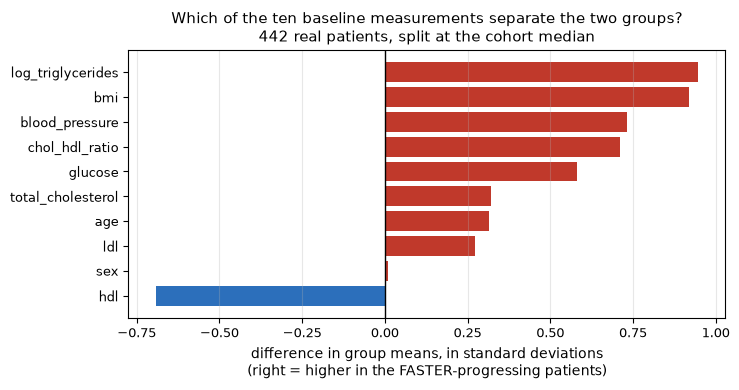


Training set: 353 samples
Test set: 89 samples
Features per patient: 10


In [2]:
# Load the REAL diabetes cohort: 442 patients, 10 clinician-measured baseline variables.
# scaled=False gives us the raw clinical units (age in years, BMI, mg/dL) so the EDA below
# shows numbers a doctor would recognise, instead of pre-standardised z-scores.
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes

diabetes = load_diabetes(scaled=False, as_frame=True)
df = diabetes.frame.copy()

# Rename the terse published column codes to what they actually measure.
df = df.rename(columns={
    "bp": "blood_pressure",       # average blood pressure
    "s1": "total_cholesterol",    # tc
    "s2": "ldl",                  # low-density lipoproteins
    "s3": "hdl",                  # high-density lipoproteins
    "s4": "chol_hdl_ratio",       # tch
    "s5": "log_triglycerides",    # ltg
    "s6": "glucose",              # glu, blood sugar level
})

# Binarise the REAL continuous target at the cohort median.
# 1 = this patient's disease progressed FASTER than the median patient in the study.
median_progression = df["target"].median()
df["fast_progression"] = (df["target"] > median_progression).astype(int)

FEATURES = ["age", "sex", "bmi", "blood_pressure", "total_cholesterol", "ldl",
            "hdl", "chol_hdl_ratio", "log_triglycerides", "glucose"]

print("=== Dataset Overview (REAL patients) ===")
print(f"Source: Efron, Hastie, Johnstone & Tibshirani (2004) diabetes cohort")
print(f"Total samples: {len(df)} real patients")
print(f"Median one-year progression score in this cohort: {median_progression:.1f}")
print(f"Faster than median: {df['fast_progression'].sum()} "
      f"({df['fast_progression'].mean():.1%})")
print(f"Slower or equal:    {(1 - df['fast_progression']).sum()} "
      f"({(1 - df['fast_progression']).mean():.1%})")
print("\nFirst few rows (raw clinical units):")
print(df[FEATURES + ["target", "fast_progression"]].head())

# EDA: Check for missing values
print("\n=== EDA: Missing Values ===")
print(df[FEATURES + ["fast_progression"]].isnull().sum())

# EDA: what do the real measurements actually look like?
print("\n=== EDA: Real Measurement Ranges ===")
print(df[FEATURES].describe().T[["mean", "std", "min", "max"]].round(2))

# EDA: which measurements differ most between the two real groups?
print("\n=== EDA: Group Means (faster vs slower progression) ===")
group_means = df.groupby("fast_progression")[FEATURES].mean()
diff = (group_means.loc[1] - group_means.loc[0]) / df[FEATURES].std()
print("Difference in standard deviations (positive = higher in the faster-progressing group):")
for feat, d in diff.sort_values(ascending=False).items():
    print(f"  {feat:20s}: {d:+.2f}")

# SEE THE SIGNAL BEFORE TRAINING ANYTHING. The ten lines above are the whole reason a model
# can beat the coin-flip baseline at all; as a chart you can read them in one second and say
# which measurements a clinician would actually pay for.
import matplotlib.pyplot as plt

diff_sorted = diff.sort_values()
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.barh(diff_sorted.index, diff_sorted.values,
        color=["#2c6fbb" if v < 0 else "#c0392b" for v in diff_sorted.values])
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("difference in group means, in standard deviations\n"
              "(right = higher in the FASTER-progressing patients)")
ax.set_title(f"Which of the ten baseline measurements separate the two groups?\n"
             f"{len(df)} real patients, split at the cohort median", fontsize=11)
ax.tick_params(labelsize=9)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Prepare data
X = df[FEATURES].values
y = df["fast_progression"].values

# Split data
# Standard preparation: split, then scale features so no single unit (mg/dL vs BMI) dominates training.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nTraining set: {X_train_scaled.shape[0]} samples")
print(f"Test set: {X_test_scaled.shape[0]} samples")
print(f"Features per patient: {X_train_scaled.shape[1]}")

### 📊 Read the EDA chart

**Two measurements do most of the work.** Log-triglycerides (**+0.95 standard deviations**) and
BMI (**+0.92**) are the longest bars: the faster-progressing patients sit almost a full standard
deviation above the slower ones on both. Blood pressure (**+0.73**) and the cholesterol/HDL ratio
(**+0.71**) follow. This is the signal the network is about to find, and it is why the model can
beat a coin flip at all.

**One bar points the other way, and it is the interesting one.** HDL is **−0.69** — the
faster-progressing patients have *less* of it. HDL is the cholesterol fraction clinicians call
"good", so a negative bar here is the chart agreeing with medicine rather than contradicting it.

**One bar is essentially zero.** `sex` sits at **+0.01**: in this cohort it does not separate the
two groups at all. That does not make it useless — it may still matter in combination with other
measurements, which is exactly the kind of interaction a neural network can represent and a
column-by-column table like this one cannot show.

**What this proves — and what it does not.** Every bar here is a *single-feature* comparison of
group averages. None of them is a prediction, and a long bar is not proof that a model will
succeed: the bars say the two groups differ, not that any individual patient can be classified.
That question needs the held-out test set below.

In [3]:
# Build FFNN model
# Fix every random source (weight init, shuffling, dropout draws) before building the
# network. Without this, each run trains a slightly different model and every metric
# quoted in the text below would drift — the numbers a student reads must be the numbers
# the cell produces.
keras.utils.set_random_seed(37)

# 442 real patients is a SMALL dataset, so we keep the network small too — a large
# network would simply memorise the training patients instead of learning from them.
model = Sequential([
 keras.Input(shape=(X_train_scaled.shape[1],)),
 Dense(32, activation='relu'),
 Dense(16, activation='relu'),
 Dense(1, activation='sigmoid') # Binary classification
])

model.compile(
 optimizer='adam', loss='binary_crossentropy',
 metrics=['accuracy']
)

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = model.fit(
 X_train_scaled, y_train,
 validation_split=0.2,
 epochs=100,
 batch_size=32,
 callbacks=[early_stopping],
 verbose=0
)

# Evaluate
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

majority_baseline = max(y_test.mean(), 1 - y_test.mean())

print("=== Model Performance (real patients, held-out test set) ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"\nMajority-class baseline: {majority_baseline:.4f} "
      f"(what you would score by always guessing the more common class)")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=['Slower progression', 'Faster progression']))

print("\n\u26a0\ufe0f  Read these numbers as a clinician would. Recall is what matters most here:")
print(f"   we caught {recall:.0%} of the patients whose disease actually progressed faster")
print(f"   than the median \u2014 the rest were missed. On real medical data a model does NOT")
print("   reach 99% accuracy, and any tutorial that shows one is almost certainly")
print("   predicting labels it invented itself.")

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


=== Model Performance (real patients, held-out test set) ===
Accuracy: 0.7303
Precision: 0.7083
Recall: 0.7727
F1-score: 0.7391

Majority-class baseline: 0.5056 (what you would score by always guessing the more common class)

Classification Report:
                    precision    recall  f1-score   support

Slower progression       0.76      0.69      0.72        45
Faster progression       0.71      0.77      0.74        44

          accuracy                           0.73        89
         macro avg       0.73      0.73      0.73        89
      weighted avg       0.73      0.73      0.73        89


⚠️  Read these numbers as a clinician would. Recall is what matters most here:
   we caught 77% of the patients whose disease actually progressed faster
   than the median — the rest were missed. On real medical data a model does NOT
   reach 99% accuracy, and any tutorial that shows one is almost certainly
   predicting labels it invented itself.


## 📊 The model against the only baseline that matters

The evaluation cell printed the network's four metrics *and* the score of the
laziest possible model, on the same 89 held-out patients:

| | accuracy | what it does |
|---|---|---|
| Majority-class baseline | **0.5056** | guess the more common class for every patient |
| Feedforward network | **0.7303** | reads ten clinical measurements |
| **Margin** | **+0.225** | about **20 of 89** patients correctly reclassified |

**The conclusion these numbers support:** the ten baseline measurements carry real
predictive signal — the network is right about twenty more patients than a coin
weighted to the common class. That is a genuine result on real clinical data.

**The conclusion they do not support:** that this model is ready for a ward. Look
at the split: precision **0.7083** and recall **0.7727** are not the same number,
and they describe two different failures. Recall says roughly ten fast progressors
were missed. Precision says roughly three in ten flagged patients were not
actually fast progressors. **Accuracy averaged those two into one figure and hid
the trade-off** — which, as the Epic sepsis case at the top of this notebook shows,
is the exact place where deployed clinical models fail.


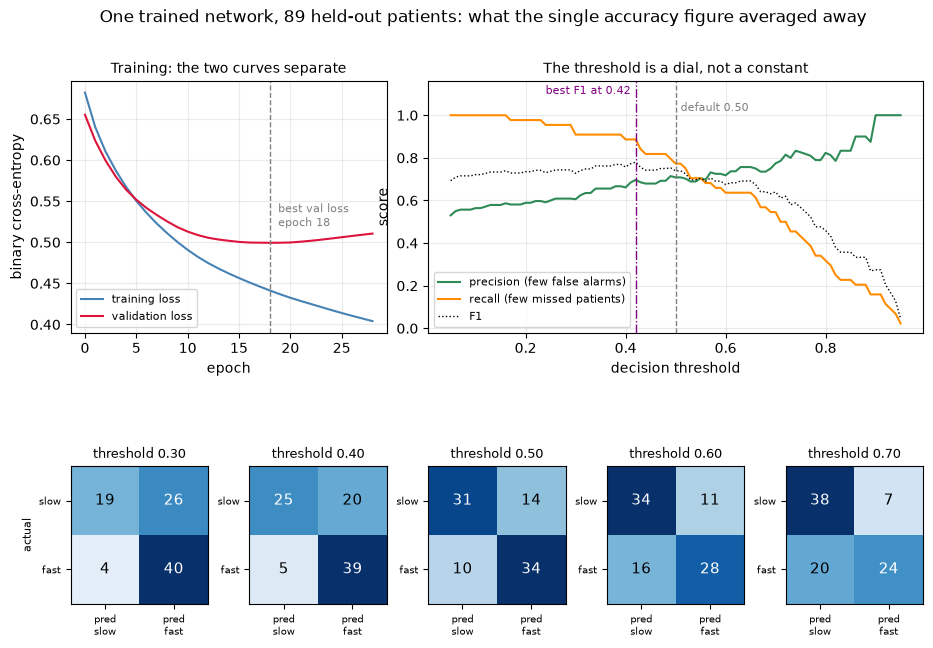

Step table for the storyboard (89 held-out patients; 44 of them really were fast progressors):
frame  threshold  flagged  caught  missed  false alarms  precision  recall
    1       0.30       66      40       4            26      0.606   0.909
    2       0.40       59      39       5            20      0.661   0.886
    3       0.50       48      34      10            14      0.708   0.773
    4       0.60       39      28      16            11      0.718   0.636
    5       0.70       31      24      20             7      0.774   0.545

Moving the dial 0.30 -> 0.70 changes NOTHING about the trained network. It changes who
gets flagged: missed patients 4 -> 20, false alarms 26 -> 7.
Every frame is the same model. Choosing among them is a clinical decision, not a technical one.


In [4]:
# SEE THE TRADE-OFF THE ACCURACY NUMBER HID.
# WHAT: three views of the SAME trained network on the SAME 89 held-out patients —
#   (1) how training went, (2) precision/recall/F1 as we slide the decision threshold,
#   (3) a five-frame storyboard of the confusion matrix as that threshold moves 0.3 -> 0.7.
# WHY: 0.5 is a default, not a decision. Discussion question 1 asks which error you would
# rather reduce and what moving the threshold does to the other one. This is that question,
# drawn in patients, so you can answer it by pointing rather than by guessing.
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

proba = y_pred_proba.ravel()                       # the network's probability per test patient
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]        # the five storyboard frames

fig = plt.figure(figsize=(11, 7.2))
gs = fig.add_gridspec(2, len(THRESHOLDS), height_ratios=[1.25, 1.0], hspace=0.45, wspace=0.3)

# --- Panel 1: did this small network overfit 353 patients? Train vs validation loss. ---
ax = fig.add_subplot(gs[0, :2])
ax.plot(history.history["loss"], color="steelblue", label="training loss")
ax.plot(history.history["val_loss"], color="crimson", label="validation loss")
best_epoch = int(np.argmin(history.history["val_loss"]))
ax.axvline(best_epoch, color="grey", linestyle="--", linewidth=1)
ax.annotate(f"best val loss\nepoch {best_epoch}", xy=(best_epoch, min(history.history["val_loss"])),
            xytext=(6, 12), textcoords="offset points", fontsize=8, color="grey")
ax.set_xlabel("epoch"); ax.set_ylabel("binary cross-entropy")
ax.set_title("Training: the two curves separate", fontsize=10); ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# --- Panel 2: slide the threshold and watch precision and recall move in opposite directions. ---
ax = fig.add_subplot(gs[0, 2:])
grid = np.linspace(0.05, 0.95, 91)
prec = [precision_score(y_test, (proba > t).astype(int), zero_division=0) for t in grid]
rec = [recall_score(y_test, (proba > t).astype(int), zero_division=0) for t in grid]
f1s = [f1_score(y_test, (proba > t).astype(int), zero_division=0) for t in grid]
ax.plot(grid, prec, color="seagreen", label="precision (few false alarms)")
ax.plot(grid, rec, color="darkorange", label="recall (few missed patients)")
ax.plot(grid, f1s, color="black", linewidth=1, linestyle=":", label="F1")
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
best_t = float(grid[int(np.argmax(f1s))])
ax.axvline(best_t, color="purple", linestyle="-.", linewidth=1)
# Label the two vertical lines ABOVE the plotting area: written on the curves they sat
# directly across precision, recall and F1 exactly where those three lines are closest.
ax.set_ylim(-0.02, 1.16)
ax.text(best_t - 0.01, 1.10, f"best F1 at {best_t:.2f}", fontsize=8, color="purple", ha="right")
ax.text(0.51, 1.02, "default 0.50", fontsize=8, color="grey", ha="left")
ax.set_xlabel("decision threshold"); ax.set_ylabel("score")
ax.set_title("The threshold is a dial, not a constant", fontsize=10)
ax.legend(fontsize=8, loc="lower left"); ax.grid(alpha=0.25)

# --- Row 2: the storyboard. The same 89 patients re-sorted at five thresholds. ---
step_rows = []
for j, t in enumerate(THRESHOLDS):
    y_t = (proba > t).astype(int)
    cm = confusion_matrix(y_test, y_t, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    ax = fig.add_subplot(gs[1, j])
    ax.imshow(cm, cmap="Blues", vmin=0, vmax=cm.max())
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", fontsize=11,
                    color="white" if cm[r, c] > cm.max() * 0.6 else "black")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["pred\nslow", "pred\nfast"], fontsize=7)
    ax.set_yticks([0, 1]); ax.set_yticklabels(["slow", "fast"], fontsize=7)
    ax.set_title(f"threshold {t:.2f}", fontsize=9)
    if j == 0:
        ax.set_ylabel("actual", fontsize=8)
    step_rows.append((t, tp, fp, fn, tn,
                      precision_score(y_test, y_t, zero_division=0),
                      recall_score(y_test, y_t, zero_division=0)))

fig.suptitle("One trained network, 89 held-out patients: what the single accuracy figure averaged away",
             fontsize=12)
plt.show()

# The step table behind the storyboard frames — the same five frames counted in patients.
print("Step table for the storyboard (89 held-out patients; 44 of them really were fast progressors):")
print(f"{'frame':>5} {'threshold':>10} {'flagged':>8} {'caught':>7} {'missed':>7} "
      f"{'false alarms':>13} {'precision':>10} {'recall':>7}")
for i, (t, tp, fp, fn, tn, p_, r_) in enumerate(step_rows, start=1):
    print(f"{i:>5} {t:10.2f} {tp + fp:8d} {tp:7d} {fn:7d} {fp:13d} {p_:10.3f} {r_:7.3f}")
lo, hi = step_rows[0], step_rows[-1]
print(f"\nMoving the dial 0.30 -> 0.70 changes NOTHING about the trained network. It changes who")
print(f"gets flagged: missed patients {lo[3]} -> {hi[3]}, false alarms {lo[2]} -> {hi[2]}.")
print(f"Every frame is the same model. Choosing among them is a clinical decision, not a technical one.")

### 📊 Read the figure

**Top left — the two curves separate, and that is why early stopping is in this notebook.**
Training loss (blue) falls without pause, all the way to about 0.40. Validation loss (red) tracks
it for the first five epochs, bottoms out at **epoch 18** around 0.50, and then turns *upward*
while blue keeps descending. Everything to the right of the dashed line is the network learning
the 353 training patients rather than the disease. `EarlyStopping(patience=10)` is what stopped
the run near epoch 28 and put the epoch-18 weights back — the metrics you read above are that
model, not the one at the end of the x-axis.

**Top right — precision and recall move in opposite directions, always.** Slide the threshold
right and green (precision) climbs while orange (recall) falls; they cross between 0.50 and 0.60.
There is no setting where both are high. The dotted F1 line peaks at **0.42**, *below* the default
0.50 the notebook used — meaning the default was already a choice, and not the best one by that
particular criterion.

**Bottom row — the same 89 patients, re-sorted five times.** Read the step table alongside it. At
threshold 0.30 the model misses only **4** fast progressors but raises **26** false alarms. At
0.70 the false alarms drop to **7** and the misses rise to **20** — half the fast progressors gone
unflagged. The middle frame, threshold 0.50, is the confusion matrix behind every number printed
above: 34 caught, 10 missed, 14 false alarms.

**What this proves.** The network was trained once and never retrained; not one weight differs
between those five frames. The entire spread — from "misses almost nobody, cries wolf constantly"
to "quiet, and blind to half the cases" — comes from moving one number a human chose. That is why
the Epic sepsis model's 18% alert rate was a deployment failure rather than a modelling failure,
and it is why **reporting a single accuracy figure conceals the only decision that mattered.**
Discussion question 1 asks which error you would rather reduce: pick a frame, and say who pays.

## 💬 Discuss

Argue from the printed results: accuracy **0.7303**, precision **0.7083**, recall
**0.7727**, F1 **0.7391**, against a majority-class baseline of **0.5056** on
**89** held-out patients.

1. Recall **0.7727** means the model caught about 34 of the 44 fast progressors
   and **missed about 10**. Precision **0.7083** means that of everyone it
   flagged, roughly 3 in 10 were not actually fast progressors. **Which of those
   two errors would you rather reduce, and what would you do to the decision
   threshold to reduce it?** Say explicitly what the other number does when you move it.
2. The Epic model alerted on 18% of hospitalisations and clinicians stopped
   trusting it. **At what false-alarm rate would you expect the doctors in a Saudi hospital
   to start ignoring your model?** You cannot look this up — argue it from how the
   ward works, and say how you would measure whether it had happened.
3. The label here is "progressed faster than the cohort median". A patient one
   point above the median and one point below get opposite labels. **Is that a
   defensible clinical target?** Propose an alternative framing, and say what you
   lose by adopting it.
4. 89 test patients. Work out roughly how much a single patient moves the accuracy
   figure, then decide what you would say to a manager who asks whether this model
   is better than the 0.73-scoring model your colleague trained.


## ⚠️ Where this breaks

- **89 test patients is a very small test set.** One patient is worth about 1.1
  percentage points of accuracy, and the 95% interval around 0.73 at n = 89 spans
  roughly ±9 points. Every metric in the report carries that uncertainty, and
  comparing two models that differ by less than it is meaningless.
- **The median split is an artificial dichotomy.** The published target is
  continuous disease progression; we cut it at 140.5 to make a classification
  exercise. Patients either side of that line are clinically almost identical and
  are given opposite labels, which puts an irreducible error floor right in the
  middle of the data. **Use instead:** predict the continuous score (regression)
  and let the clinician choose a threshold, or model it as ordinal.
- **A 50/50 class balance is a laboratory condition.** It comes from splitting at
  the median. Real screening problems are imbalanced, and the accuracy figure that
  is informative here would be misleading there.
- **This cohort is not your population.** The Efron et al. data is a specific
  research cohort from a specific place and time. The Epic case is exactly the
  lesson: a model validated internally and deployed elsewhere lost most of its
  performance. **External validation on data from another site is not optional**,
  and nothing in this notebook is one.
- **The model outputs a probability that has not been calibrated.** Thresholding
  it at 0.5 is a default, not a decision. The right threshold depends on the cost
  of a missed case against the cost of a false alarm, and nobody in this notebook
  wrote those costs down.
- **A neural network is not the natural choice for 442 rows and 10 columns.**
  Logistic regression and gradient-boosted trees are strong, faster and far easier
  to explain on tabular data of this size — and explanation is a hard requirement
  in a clinical setting. Course 04 builds those comparisons; treat this FFNN as a
  demonstration of the recipe, not as the recommended tool.


## 📚 References

1. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning Representations by Back-Propagating Errors*. Nature, 323, 533–536.
2. Smith, J. W., Everhart, J. E., Dickson, W. C., et al. (1988). *Using the ADAP Learning Algorithm to Forecast the Onset of Diabetes Mellitus* (Pima Indians diabetes study). Proceedings of the Annual Symposium on Computer Applications in Medical Care.
3. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*, Ch. 6: Deep Feedforward Networks (includes the XOR example). MIT Press.
4. Grinsztajn, L., Flöge, K., Key, O., et al. (2025). *TabPFN-2.5: Advancing the State of the Art in Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2511.08667>
5. Sena, L. B. T. R., & Azevedo, F. G. (2026). *Real-Time Explanations for Tabular Foundation Models*. arXiv. <https://arxiv.org/abs/2603.29946>